# Evaluation Pipeline — final_version

Pipeline under evaluation:
```
Stage 1  → Groq LLM rewrites raw ticket                        (call #1 — always)
Stage 2a → Fine-tuned DistilBERT: dept + priority classification (no API)
Stage 2b → Hybrid RAG: DistilBERT CLS → FAISS+BM25+RRF+CrossEncoder (no API, always)
Stage 3  → Groq LLM decides dept + priority from all 3 sources  (call #2 — always)
```

| Section | What | API calls |
|---|---|---|
| 1 | Transformer standalone — accuracy, F1, calibration, ECE | None |
| 2 | RAG retrieval — Recall@K, MRR, CE distributions | None |
| 3 | Full pipeline — accuracy, LLM override rate, TTFT, TPOT | 2/ticket |
| 4 | AI-as-a-judge — rewrite quality, reasoning quality, routing quality | 3/ticket |

In [2]:
import os, sys, time, json, re, warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

OUT_DIR = os.path.join(ROOT, 'outputs', 'evaluation')
os.makedirs(OUT_DIR, exist_ok=True)

TRANSFORMER_RESULTS_PATH = os.path.join(OUT_DIR, 'transformer_results.csv')
RAG_RESULTS_PATH         = os.path.join(OUT_DIR, 'rag_retrieval_results.csv')
PIPELINE_RESULTS_PATH    = os.path.join(OUT_DIR, 'pipeline_results.csv')
JUDGE_RESULTS_PATH       = os.path.join(OUT_DIR, 'judge_results.csv')

from dotenv import load_dotenv
load_dotenv(os.path.join(ROOT, 'secrets.env'))
HF_TOKEN   = os.getenv('HF_TOKEN')
GROQ_TOKEN = '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'
assert HF_TOKEN   and HF_TOKEN.startswith('hf_'),   'HF_TOKEN missing'
assert GROQ_TOKEN and GROQ_TOKEN.startswith('gsk_'), 'GROQ_API_KEY missing'
print('Secrets loaded')
print(f'Outputs: {OUT_DIR}')

Secrets loaded
Outputs: /Users/avani/IdeaProjects/customer-support-management/outputs/evaluation


In [3]:
import torch
import pandas as pd
import numpy as np
from groq import Groq

from pipeline.stage2a_transformer import load_transformer, transformer_predict
from pipeline.stage2b_retriever   import load_rag_artifacts, hybrid_retrieve, retrieve_priority_chunk
from pipeline.router               import route_ticket

# device      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'mps'
groq_client = Groq(api_key=GROQ_TOKEN)
print(f'Device: {device}')

print('Loading transformer...')
model, tokenizer, queue_encoder, priority_encoder = load_transformer(
    'Nethra19/multitask-ticket-model', HF_TOKEN, device
)
print('Loading RAG artifacts...')
faiss_index, bm25, all_chunks, cross_encoder, priority_index, priority_chunks = load_rag_artifacts(
    'avani1010/new_index', HF_TOKEN
)
print('All components ready')

All components ready


In [4]:
test_df = pd.read_csv(os.path.join(ROOT, 'data/processed/test.csv'))
test_df['raw_text'] = (test_df['subject'].fillna('') + ' ' + test_df['body'].fillna('')).str.strip()

print(f'Test set: {len(test_df)} tickets')
print(test_df['queue'].value_counts())

# 30 per dept for Sections 1+2 — no API cost
eval_df = pd.concat([
    group.sample(min(len(group), 30), random_state=42)
    for _, group in test_df.groupby('queue')
]).reset_index(drop=True)

# 3 per dept for Sections 3+4 — 2 Groq calls each
pipeline_df = pd.concat([
    group.sample(min(len(group), 10), random_state=42)
    for _, group in test_df.groupby('queue')
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Eval sample (Sec 1+2): {len(eval_df)} | Pipeline sample (Sec 3+4): {len(pipeline_df)}')

Test set: 7387 tickets
queue
Technical & IT Support             4385
Customer Service                   1127
Billing and Payments                763
Returns and Exchanges               365
Service Outages and Maintenance     299
Sales and Pre-Sales                 208
Human Resources                     140
General Inquiry                     100
Name: count, dtype: int64
Eval sample (Sec 1+2): 240 | Pipeline sample (Sec 3+4): 80


---
## Section 1 — Transformer Standalone (Stage 2a)
No API calls. DistilBERT classifier in isolation — this is the baseline before RAG or LLM.

In [4]:
from tqdm import tqdm

if os.path.exists(TRANSFORMER_RESULTS_PATH):
    trans_df = pd.read_csv(TRANSFORMER_RESULTS_PATH)
    print(f'Loaded cached transformer results ({len(trans_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        r = transformer_predict(
            row['raw_text'], model, tokenizer, queue_encoder, priority_encoder, device
        )
        records.append({
            'true_dept'    : row['queue'],    'true_priority': row['priority'],
            'pred_dept'    : r['dept'],        'dept_conf'    : r['dept_conf'],
            'pred_priority': r['priority'],    'priority_conf': r['priority_conf'],
        })
    trans_df = pd.DataFrame(records)
    trans_df.to_csv(TRANSFORMER_RESULTS_PATH, index=False)
    print(f'Saved {len(trans_df)} rows')

Loaded cached transformer results (240 rows)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

dept_acc = accuracy_score(trans_df['true_dept'],     trans_df['pred_dept'])
dept_f1  = f1_score(trans_df['true_dept'],     trans_df['pred_dept'],     average='macro', zero_division=0)
prio_acc = accuracy_score(trans_df['true_priority'], trans_df['pred_priority'])
prio_f1  = f1_score(trans_df['true_priority'], trans_df['pred_priority'], average='macro', zero_division=0)

print('=' * 55)
print('TRANSFORMER STANDALONE')
print('=' * 55)
print(f'Dept  Accuracy: {dept_acc*100:.1f}%  Macro F1: {dept_f1*100:.1f}%')
print(f'Prio  Accuracy: {prio_acc*100:.1f}%  Macro F1: {prio_f1*100:.1f}%')
print()
print('DEPARTMENT REPORT:')
print(classification_report(trans_df['true_dept'], trans_df['pred_dept'], zero_division=0))
print('PRIORITY REPORT:')
print(classification_report(trans_df['true_priority'], trans_df['pred_priority'], zero_division=0))

TRANSFORMER STANDALONE
Dept  Accuracy: 50.4%  Macro F1: 49.4%
Prio  Accuracy: 60.0%  Macro F1: 58.0%

DEPARTMENT REPORT:
                                 precision    recall  f1-score   support

           Billing and Payments       0.87      0.87      0.87        30
               Customer Service       0.28      0.47      0.35        30
                General Inquiry       1.00      0.07      0.12        30
                Human Resources       1.00      0.30      0.46        30
          Returns and Exchanges       0.67      0.47      0.55        30
            Sales and Pre-Sales       0.86      0.20      0.32        30
Service Outages and Maintenance       0.96      0.77      0.85        30
         Technical & IT Support       0.28      0.90      0.43        30

                       accuracy                           0.50       240
                      macro avg       0.74      0.50      0.49       240
                   weighted avg       0.74      0.50      0.49       240



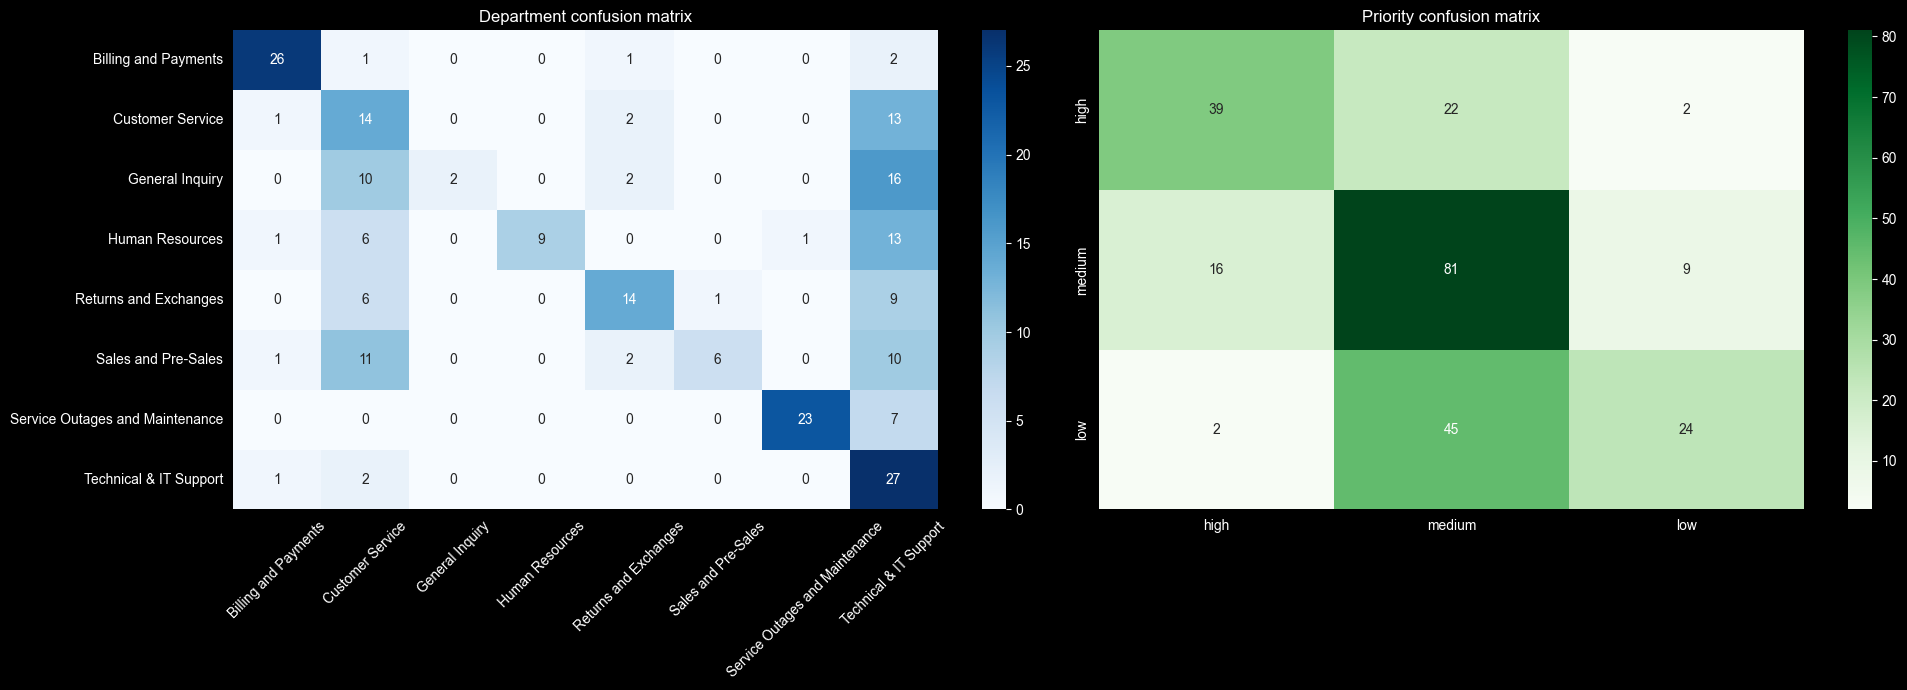

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
dept_labels = sorted(trans_df['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

sns.heatmap(confusion_matrix(trans_df['true_dept'], trans_df['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues', xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0])
axes[0].set_title('Department confusion matrix'); axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(confusion_matrix(trans_df['true_priority'], trans_df['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens', xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1])
axes[1].set_title('Priority confusion matrix')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'transformer_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

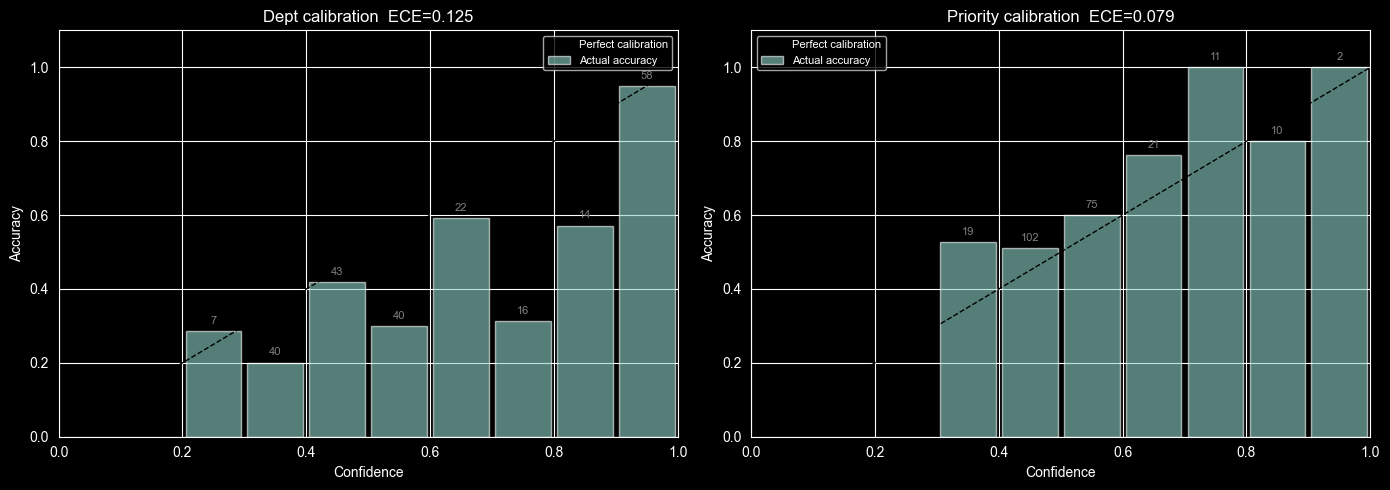

In [7]:
# Confidence calibration + ECE
# For each confidence bucket: what is the actual accuracy?
# ECE = weighted average of |confidence - accuracy|. Lower = better calibrated.

def calibration_data(df, conf_col, correct_col, n=10):
    bins = np.linspace(0, 1, n + 1)
    mids, accs, counts = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = df[(df[conf_col] >= lo) & (df[conf_col] < hi)]
        if len(s) == 0: continue
        mids.append((lo+hi)/2); accs.append(s[correct_col].mean()); counts.append(len(s))
    return np.array(mids), np.array(accs), np.array(counts)

def ece(mids, accs, counts):
    return float(np.sum(counts * np.abs(mids - accs)) / counts.sum())

trans_df['dept_correct'] = (trans_df['pred_dept']     == trans_df['true_dept']).astype(int)
trans_df['prio_correct'] = (trans_df['pred_priority'] == trans_df['true_priority']).astype(int)

d_m, d_a, d_c = calibration_data(trans_df, 'dept_conf',     'dept_correct')
p_m, p_a, p_c = calibration_data(trans_df, 'priority_conf', 'prio_correct')
dept_ece = ece(d_m, d_a, d_c)
prio_ece = ece(p_m, p_a, p_c)
print(f'Department ECE: {dept_ece:.4f}  |  Priority ECE: {prio_ece:.4f}  (lower = better)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mids, accs, counts, ece_val, title in [
    (axes[0], d_m, d_a, d_c, dept_ece, f'Dept calibration  ECE={dept_ece:.3f}'),
    (axes[1], p_m, p_a, p_c, prio_ece, f'Priority calibration  ECE={prio_ece:.3f}'),
]:
    w = mids[1]-mids[0] if len(mids)>1 else 0.1
    ax.bar(mids, accs, width=w*0.9, alpha=0.6, label='Actual accuracy')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
    for m,a,c in zip(mids,accs,counts): ax.text(m,a+0.02,str(c),ha='center',fontsize=8,color='grey')
    ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.set_xlabel('Confidence'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — RAG Retrieval (Stage 2b)
No API calls. Uses `model.encoder` (DistilBERT CLS token) exactly as the pipeline does.
Evaluates whether the correct dept chunk and priority chunk are retrieved.

In [8]:
if os.path.exists(RAG_RESULTS_PATH):
    rag_df = pd.read_csv(RAG_RESULTS_PATH)
    print(f'Loaded cached RAG results ({len(rag_df)} rows)')
else:
    records = []
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        query     = row['raw_text']
        true_dept = row['queue']
        true_prio = row['priority'].lower()

        # Dept retrieval — identical call to pipeline
        chunks = hybrid_retrieve(
            query, model.encoder, tokenizer, device,
            faiss_index, bm25, all_chunks, cross_encoder, top_n_final=4
        )
        depts  = [c['chunk']['dept'] for c in chunks]
        scores = [c['ce_score'] for c in chunks]
        r1  = int(depts[0] == true_dept) if depts else 0
        r4  = int(true_dept in depts)
        mrr = next((1.0/(r+1) for r,d in enumerate(depts) if d==true_dept), 0.0)

        # Priority retrieval — identical call to pipeline
        pc = retrieve_priority_chunk(
            query, model.encoder, tokenizer, device,
            priority_index, priority_chunks, cross_encoder
        )
        prio_sect = pc['chunk']['section'].lower() if pc else 'none'
        prio_ce   = pc['ce_score'] if pc else 0.0

        records.append({
            'true_dept'    : true_dept,   'true_priority': true_prio,
            'top1_dept'    : depts[0] if depts else '',
            'recall_at_1'  : r1,          'recall_at_4'  : r4,
            'mrr'          : mrr,          'top_ce_score' : scores[0] if scores else 0.0,
            'prio_section' : prio_sect,    'prio_ce_score': prio_ce,
            'prio_correct' : int(prio_sect == true_prio),
        })

    rag_df = pd.DataFrame(records)
    rag_df.to_csv(RAG_RESULTS_PATH, index=False)
    print(f'Saved {len(rag_df)} rows')

Loaded cached RAG results (240 rows)


In [9]:
print('=' * 55)
print('RAG RETRIEVAL RESULTS')
print('=' * 55)
print(f'Dept  Recall@1 : {rag_df["recall_at_1"].mean()*100:.1f}%')
print(f'Dept  Recall@4 : {rag_df["recall_at_4"].mean()*100:.1f}%')
print(f'Dept  MRR      : {rag_df["mrr"].mean():.3f}')
print(f'Prio  Section  : {rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')
print()
print('Recall@1 per department:')
per_dept = rag_df.groupby('true_dept')['recall_at_1'].agg(['mean','count']).rename(
    columns={'mean':'Recall@1','count':'N'}).sort_values('Recall@1', ascending=False)
per_dept['Recall@1'] = (per_dept['Recall@1']*100).round(1).astype(str)+'%'

print(per_dept)

RAG RETRIEVAL RESULTS
Dept  Recall@1 : 38.3%
Dept  Recall@4 : 55.0%
Dept  MRR      : 0.450
Prio  Section  : 38.3%  (random baseline 33.3%)

Recall@1 per department:
                                Recall@1   N
true_dept                                   
Billing and Payments               53.3%  30
Sales and Pre-Sales                53.3%  30
Technical & IT Support             43.3%  30
Service Outages and Maintenance    40.0%  30
General Inquiry                    36.7%  30
Returns and Exchanges              33.3%  30
Customer Service                   30.0%  30
Human Resources                    16.7%  30


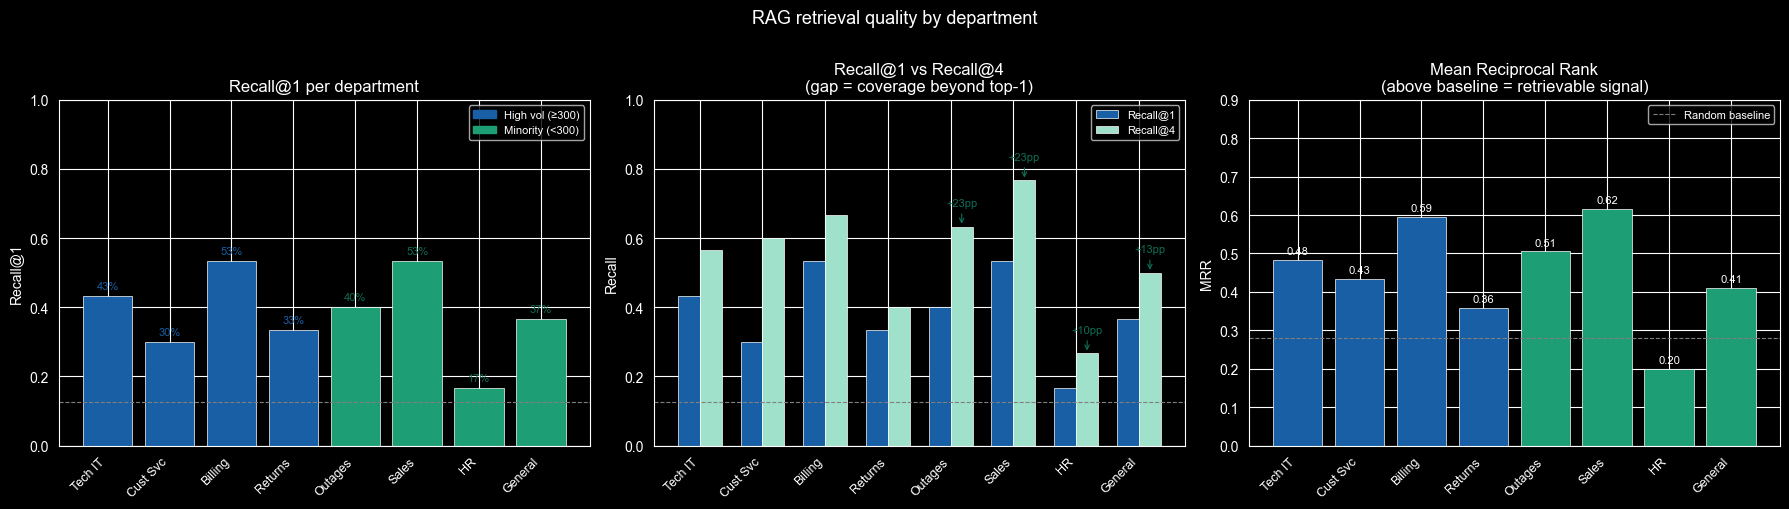

In [10]:
import matplotlib.patches as mpatches

dept_volume = {
    'Technical & IT Support':4385,'Customer Service':1127,'Billing and Payments':763,
    'Returns and Exchanges':365,'Service Outages and Maintenance':299,
    'Sales and Pre-Sales':208,'Human Resources':140,'General Inquiry':100,
}
depts_sorted = sorted(dept_volume, key=lambda d: dept_volume[d], reverse=True)
short = ['Tech IT','Cust Svc','Billing','Returns','Outages','Sales','HR','General']
is_minority = [dept_volume[d] < 300 for d in depts_sorted]
c1 = ['#185FA5' if not m else '#1D9E75' for m in is_minority]

r1_  = rag_df.groupby('true_dept')['recall_at_1'].mean().reindex(depts_sorted).values
r4_  = rag_df.groupby('true_dept')['recall_at_4'].mean().reindex(depts_sorted).values
mrr_ = rag_df.groupby('true_dept')['mrr'].mean().reindex(depts_sorted).values
x, w = np.arange(len(depts_sorted)), 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RAG retrieval quality by department', fontsize=13, y=1.01)

bars = axes[0].bar(x, r1_, color=c1, edgecolor='white', linewidth=0.5)
axes[0].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0,1); axes[0].set_ylabel('Recall@1'); axes[0].set_title('Recall@1 per department')
for b,v,m in zip(bars,r1_,is_minority):
    axes[0].text(b.get_x()+b.get_width()/2,v+0.02,f'{v*100:.0f}%',ha='center',fontsize=8,
                 color='#0F6E56' if m else '#185FA5')
axes[0].legend(handles=[mpatches.Patch(color='#185FA5',label='High vol (≥300)'),
                         mpatches.Patch(color='#1D9E75',label='Minority (<300)')],fontsize=8)

axes[1].bar(x-w/2, r1_, w, label='Recall@1', color='#185FA5', edgecolor='white', linewidth=0.5)
axes[1].bar(x+w/2, r4_, w, label='Recall@4', color='#9FE1CB', edgecolor='white', linewidth=0.5)
axes[1].axhline(1/8, color='grey', linestyle='--', lw=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim(0,1); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall@1 vs Recall@4\n(gap = coverage beyond top-1)'); axes[1].legend(fontsize=8)
for i in range(len(x)):
    if is_minority[i] and r4_[i]>r1_[i]:
        axes[1].annotate(f'+{(r4_[i]-r1_[i])*100:.0f}pp',
            xy=(x[i]+w/2,r4_[i]),xytext=(x[i]+w/2,r4_[i]+0.06),ha='center',fontsize=8,
            color='#0F6E56',arrowprops=dict(arrowstyle='->',color='#0F6E56',lw=0.8))

bars3 = axes[2].bar(x, mrr_, color=c1, edgecolor='white', linewidth=0.5)
axes[2].axhline(0.28, color='grey', linestyle='--', lw=0.8, label='Random baseline')
axes[2].set_xticks(x); axes[2].set_xticklabels(short, rotation=45, ha='right', fontsize=9)
axes[2].set_ylim(0,0.9); axes[2].set_ylabel('MRR')
axes[2].set_title('Mean Reciprocal Rank\n(above baseline = retrievable signal)'); axes[2].legend(fontsize=8)
for b,v in zip(bars3,mrr_): axes[2].text(b.get_x()+b.get_width()/2,v+0.015,f'{v:.2f}',ha='center',fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'rag_retrieval_by_dept.png'),dpi=150,bbox_inches='tight')
plt.show()

---
## Section 3 — Full Pipeline: Accuracy + Latency

**Every ticket makes 2 Groq calls** (Stage 1 + Stage 3 — no gate, always runs).

**TTFT** = Stage 1 latency — the first blocking LLM call. Measured as a one-time baseline before the loop.

**TPOT** = Stage 3 estimated latency / output tokens. Stage 3 generates a reasoning paragraph — TPOT is meaningful here because the output length varies with ticket complexity.

In [11]:
from pipeline.stage1_rewriter import rewrite_query as _stage1

print('Measuring TTFT baseline (Stage 1 warm-up)...')
_t0 = time.perf_counter()
_ = _stage1(pipeline_df.iloc[0]['raw_text'], groq_client)
TTFT_BASELINE = round(time.perf_counter() - _t0, 3)
print(f'TTFT baseline: {TTFT_BASELINE:.3f}s')
time.sleep(2.0)

if os.path.exists(PIPELINE_RESULTS_PATH):
    _ex = pd.read_csv(PIPELINE_RESULTS_PATH)
    if len(_ex) > 0 and 'pred_dept' in _ex.columns:
        results_df = _ex
        print(f'Loaded cached pipeline results ({len(results_df)} rows)')
    else:
        os.remove(PIPELINE_RESULTS_PATH)

if not os.path.exists(PIPELINE_RESULTS_PATH):
    records, errors = [], 0
    for idx, row in tqdm(pipeline_df.iterrows(), total=len(pipeline_df)):
        try:
            t0 = time.perf_counter()
            res = route_ticket(
                row['raw_text'], groq_client,
                model, tokenizer, queue_encoder, priority_encoder, device,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks
            )
            t_total = round(time.perf_counter() - t0, 3)
            reasoning_tokens = max(len(res.reasoning.split()), 1)
            t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
            records.append({
                'true_dept'         : row['queue'],
                'true_priority'     : row['priority'],
                'pred_dept'         : res.department,
                'pred_priority'     : res.priority,
                'transformer_dept'  : res.transformer_dept,
                'transformer_conf'  : res.transformer_conf,
                'confidence'        : res.confidence,
                'llm_overrides_dept': int(res.department != res.transformer_dept),
                't_total_s'         : t_total,
                'ttft_s'            : TTFT_BASELINE,
                'tpot_s'            : round(t_stage3_est / reasoning_tokens, 4),
                'reasoning_tokens'  : reasoning_tokens,
            })
        except Exception as e:
            if '429' in str(e) or 'rate_limit' in str(e).lower():
                # Save progress then wait and retry the same ticket
                pd.DataFrame(records).to_csv(PIPELINE_RESULTS_PATH, index=False)
                wait = 60
                print(f'\n⚠ Rate limit at row {idx} — waiting {wait}s then retrying...')
                time.sleep(wait)
                try:
                    t0 = time.perf_counter()
                    res = route_ticket(
                        row['raw_text'], groq_client,
                        model, tokenizer, queue_encoder, priority_encoder, device,
                        faiss_index, bm25, all_chunks, cross_encoder,
                        priority_index, priority_chunks
                    )
                    t_total = round(time.perf_counter() - t0, 3)
                    reasoning_tokens = max(len(res.reasoning.split()), 1)
                    t_stage3_est     = max(t_total - TTFT_BASELINE - 0.05, 0.1)
                    records.append({
                        'true_dept'         : row['queue'],
                        'true_priority'     : row['priority'],
                        'pred_dept'         : res.department,
                        'pred_priority'     : res.priority,
                        'transformer_dept'  : res.transformer_dept,
                        'transformer_conf'  : res.transformer_conf,
                        'confidence'        : res.confidence,
                        'llm_overrides_dept': int(res.department != res.transformer_dept),
                        't_total_s'         : t_total,
                        'ttft_s'            : TTFT_BASELINE,
                        'tpot_s'            : round(t_stage3_est / reasoning_tokens, 4),
                        'reasoning_tokens'  : reasoning_tokens,
                    })
                except Exception as e2:
                    errors += 1
                    print(f'✗ Retry also failed for row {idx}: {e2}')
                    records.append({
                        'true_dept': row['queue'], 'true_priority': row['priority'],
                        'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                        'transformer_dept': '', 'transformer_conf': 0.0,
                        'confidence': 'low', 'llm_overrides_dept': 0,
                        't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0,
                    })
            else:
                errors += 1
                print(f'✗ Row {idx}: {e}')
                records.append({
                    'true_dept': row['queue'], 'true_priority': row['priority'],
                    'pred_dept': 'ERROR', 'pred_priority': 'ERROR',
                    'transformer_dept': '', 'transformer_conf': 0.0,
                    'confidence': 'low', 'llm_overrides_dept': 0,
                    't_total_s': None, 'ttft_s': None, 'tpot_s': None, 'reasoning_tokens': 0,
                })
        time.sleep(1.5)
    results_df = pd.DataFrame(records)
    results_df.to_csv(PIPELINE_RESULTS_PATH, index=False)
    print(f'Saved {len(results_df)} tickets ({errors} errors)')

if 'results_df' not in dir():
    results_df = pd.read_csv(PIPELINE_RESULTS_PATH)

In [12]:
clean = results_df[results_df['pred_dept'] != 'ERROR'].copy()
clean['dept_correct']  = (clean['pred_dept']      == clean['true_dept']).astype(int)
clean['prio_correct']  = (clean['pred_priority']  == clean['true_priority']).astype(int)
clean['trans_correct'] = (clean['transformer_dept'] == clean['true_dept']).astype(int)

print('=' * 60)
print('FULL PIPELINE END-TO-END')
print('=' * 60)
print(f'Department Accuracy : {clean["dept_correct"].mean()*100:.1f}%')
print(f'Priority   Accuracy : {clean["prio_correct"].mean()*100:.1f}%')
print(f'Total tickets       : {len(clean)}')
print()

overrides  = clean[clean['llm_overrides_dept'] == 1]
agreements = clean[clean['llm_overrides_dept'] == 0]
print(f'LLM agreed with transformer : {len(agreements)} tickets')
print(f'  Dept accuracy             : {agreements["dept_correct"].mean()*100:.1f}%')
print()
print(f'LLM overrode transformer    : {len(overrides)} tickets ({len(overrides)/max(len(clean),1)*100:.1f}%)')
if len(overrides) > 0:
    trans_on_ov = overrides['trans_correct'].mean()
    llm_on_ov   = overrides['dept_correct'].mean()
    delta = (llm_on_ov - trans_on_ov) * 100
    print(f'  Transformer accuracy on overridden tickets : {trans_on_ov*100:.1f}%')
    print(f'  LLM final accuracy on overridden tickets   : {llm_on_ov*100:.1f}%')
    print(f'  LLM override improvement                   : {delta:+.1f}pp')
    print(f'  (positive = LLM corrected transformer mistakes)')

FULL PIPELINE END-TO-END
Department Accuracy : 51.2%
Priority   Accuracy : 53.8%
Total tickets       : 80

LLM agreed with transformer : 55 tickets
  Dept accuracy             : 49.1%

LLM overrode transformer    : 25 tickets (31.2%)
  Transformer accuracy on overridden tickets : 20.0%
  LLM final accuracy on overridden tickets   : 56.0%
  LLM override improvement                   : +36.0pp
  (positive = LLM corrected transformer mistakes)


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print()
print('DEPARTMENT CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_dept'], clean['pred_dept'], zero_division=0))

print('PRIORITY CLASSIFICATION REPORT (full pipeline):')
print(classification_report(clean['true_priority'], clean['pred_priority'], zero_division=0))

# Confusion matrices
dept_labels = sorted(clean['true_dept'].unique())
prio_labels = ['high', 'medium', 'low']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(
    confusion_matrix(clean['true_dept'], clean['pred_dept'], labels=dept_labels),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=dept_labels, yticklabels=dept_labels, ax=axes[0]
)
axes[0].set_title('Department confusion matrix (full pipeline)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    confusion_matrix(clean['true_priority'], clean['pred_priority'], labels=prio_labels),
    annot=True, fmt='d', cmap='Greens',
    xticklabels=prio_labels, yticklabels=prio_labels, ax=axes[1]
)
axes[1].set_title('Priority confusion matrix (full pipeline)', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pipeline_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved pipeline_confusion.png')

✓ Saved pipeline_confusion.png


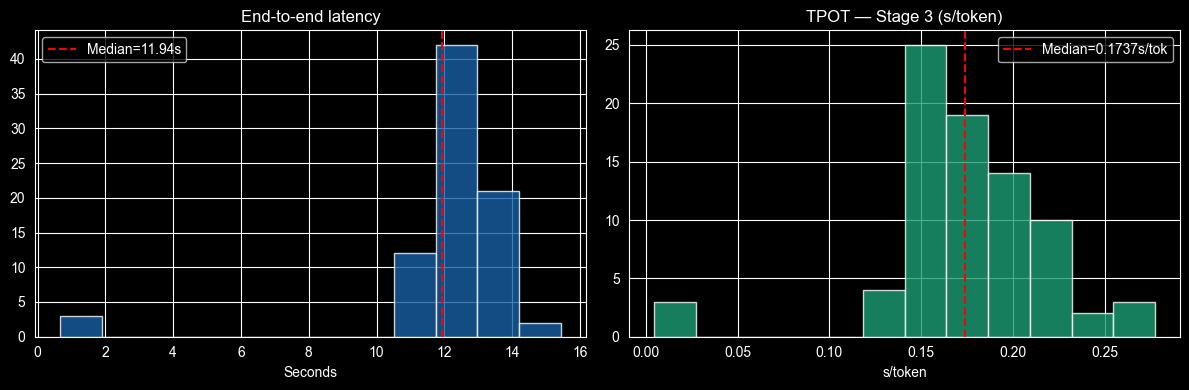

In [16]:
lat = clean[clean['t_total_s'].notna()]

print('=' * 60)
print('LATENCY METRICS')
print('=' * 60)
print(f'TTFT — Stage 1 rewrite (first Groq call, blocks all downstream stages):')
print(f'  Measured baseline : {TTFT_BASELINE:.3f}s')
print()
print(f'End-to-end latency (Stage 1 + 2a + 2b + Stage 3):')
print(f'  Mean   : {lat["t_total_s"].mean():.3f}s')
print(f'  Median : {lat["t_total_s"].median():.3f}s')
print(f'  P90    : {lat["t_total_s"].quantile(0.9):.3f}s')
print()
tpot_vals = lat[lat['tpot_s'].notna()]['tpot_s']
print(f'TPOT — Stage 3 output (generates reasoning, all tickets):')
print(f'  Mean   : {tpot_vals.mean():.4f}s/token')
print(f'  Median : {tpot_vals.median():.4f}s/token')
print(f'  Avg reasoning tokens : {lat["reasoning_tokens"].mean():.0f}')
print(f'  Reference: human reading ~0.125-0.167s/token (6-8 tokens/s)')
print()
print(f'Groq calls per ticket : always 2 (Stage 1 + Stage 3)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lat['t_total_s'].hist(bins=12, ax=axes[0], color='#185FA5', alpha=0.8)
axes[0].axvline(lat['t_total_s'].median(), color='red', linestyle='--',
                label=f'Median={lat["t_total_s"].median():.2f}s')
axes[0].set_title('End-to-end latency'); axes[0].set_xlabel('Seconds'); axes[0].legend()

tpot_vals.hist(bins=12, ax=axes[1], color='#1D9E75', alpha=0.8)
axes[1].axvline(tpot_vals.median(), color='red', linestyle='--',
                label=f'Median={tpot_vals.median():.4f}s/tok')
axes[1].set_title('TPOT — Stage 3 (s/token)'); axes[1].set_xlabel('s/token'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'latency_distributions.png'),dpi=150,bbox_inches='tight')
plt.show()

---
## Section 4 — AI-as-a-Judge

Three rubrics scored 1–3 by Groq Llama (temperature=0).  
`res.cleaned_text` and `res.reasoning` come from `RoutingResult` — no extra Stage 1 call.

In [18]:
REWRITE_RUBRIC = """Evaluate the quality of this customer support ticket rewrite.

ORIGINAL: {original}
REWRITTEN: {rewritten}

Score 1-3:
1 = Meaning changed, details lost, or department vocabulary injected not in original
2 = Meaning mostly preserved but verbose, awkward, or adds minor assumptions
3 = Meaning fully preserved, clean professional rewrite, no vocabulary injection

Respond ONLY: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""

REASONING_RUBRIC = """Evaluate whether this AI routing decision was well-justified.

TICKET: {ticket}
PREDICTED DEPT: {pred_dept} | PREDICTED PRIORITY: {pred_priority}
REASONING: {reasoning}

Score 1-3:
1 = Reasoning is vague or fabricated, does not cite transformer confidence or RAG evidence
2 = Broadly correct but generic, mentions sources without specific values
3 = Cites specific evidence (transformer confidence %, RAG dept, priority criteria) and explains decision clearly

Respond ONLY: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""

ROUTING_RUBRIC = """Evaluate the overall quality of this ticket routing decision.

TICKET: {ticket}
PREDICTED DEPT: {pred_dept} | TRUE DEPT: {true_dept}
PREDICTED PRIORITY: {pred_prio} | TRUE PRIORITY: {true_prio}
REASONING: {reasoning}

Score 1-3:
1 = Dept or priority wrong, or reasoning does not support the decision
2 = Dept correct but priority questionable, or reasoning is weak
3 = Both correct, reasoning cites specific evidence from ticket content

Respond ONLY: {{"score": <1|2|3>, "reason": "<one sentence>"}}"""


def judge(prompt, client, retries=3):
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model='llama-3.1-8b-instant',
                messages=[{'role':'user','content':prompt}],
                temperature=0.0, max_tokens=120,
            )
            m = re.search(r'\{.*?\}', resp.choices[0].message.content.strip(), re.DOTALL)
            if m: return json.loads(m.group())
        except Exception as e:
            if '429' in str(e) and attempt < retries-1: time.sleep(10); continue
            return {'score': 0, 'reason': f'error: {e}'}
    return {'score': 0, 'reason': 'max retries'}

print('Rubrics and judge function ready')

Rubrics and judge function ready


In [24]:
if os.path.exists(JUDGE_RESULTS_PATH):
    _ej = pd.read_csv(JUDGE_RESULTS_PATH)
    if len(_ej) > 0:
        judge_df = _ej
        print(f'Loaded cached judge results ({len(judge_df)} rows)')
    else:
        os.remove(JUDGE_RESULTS_PATH)

if not os.path.exists(JUDGE_RESULTS_PATH):
    judge_sample = pipeline_df.sample(min(10, len(pipeline_df)), random_state=99).reset_index(drop=True)
    print(f'Running AI judge on {len(judge_sample)} tickets...')
    jrecords = []

    for idx, row in tqdm(judge_sample.iterrows(), total=len(judge_sample)):
        try:
            res = route_ticket(
                row['raw_text'], groq_client,
                model, tokenizer, queue_encoder, priority_encoder, device,
                faiss_index, bm25, all_chunks, cross_encoder,
                priority_index, priority_chunks
            )
            time.sleep(1.5)

            # All three rubrics — res.cleaned_text used throughout, no extra Stage 1 call
            r1 = judge(REWRITE_RUBRIC.format(
                original=row['raw_text'][:400], rewritten=res.cleaned_text[:400]), groq_client)
            time.sleep(1.5)

            r2 = judge(REASONING_RUBRIC.format(
                ticket=res.cleaned_text[:400], pred_dept=res.department,
                pred_priority=res.priority, reasoning=res.reasoning[:400]), groq_client)
            time.sleep(1.5)

            r3 = judge(ROUTING_RUBRIC.format(
                ticket=res.cleaned_text[:400],
                pred_dept=res.department, true_dept=row['queue'],
                pred_prio=res.priority,   true_prio=row['priority'],
                reasoning=res.reasoning[:400]), groq_client)
            time.sleep(1.5)

            jrecords.append({
                'true_dept'        : row['queue'],
                'true_priority'    : row['priority'],
                'pred_dept'        : res.department,
                'pred_priority'    : res.priority,
                'dept_correct'     : int(res.department == row['queue']),
                'prio_correct'     : int(res.priority   == row['priority']),
                'rewrite_score'    : r1.get('score'),   'rewrite_reason'   : r1.get('reason'),
                'reasoning_score'  : r2.get('score'),   'reasoning_reason' : r2.get('reason'),
                'routing_score'    : r3.get('score'),   'routing_reason'   : r3.get('reason'),
            })
        except Exception as e:
            if '429' in str(e) or 'rate_limit' in str(e).lower():
                pd.DataFrame(jrecords).to_csv(JUDGE_RESULTS_PATH, index=False)
                print(f'Rate limit — saved {len(jrecords)} rows. Re-run to resume.'); break
            print(f'Row {idx}: {e}')
        time.sleep(2.0)
    else:
        judge_df = pd.DataFrame(jrecords)
        judge_df.to_csv(JUDGE_RESULTS_PATH, index=False)
        print(f'Judge complete — {len(judge_df)} tickets saved')

if 'judge_df' not in dir():
    judge_df = pd.read_csv(JUDGE_RESULTS_PATH)

EmptyDataError: No columns to parse from file

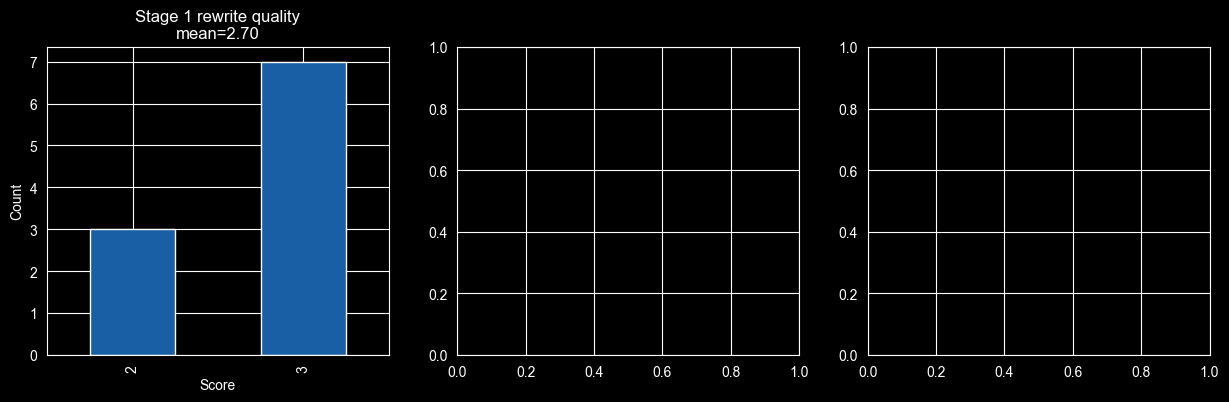

In [41]:
numeric = judge_df.copy()
for col in ['rewrite_score','reasoning_score','routing_score']:
    numeric[col] = pd.to_numeric(numeric[col], errors='coerce')

print('=' * 60)
print('AI-AS-A-JUDGE  (1=poor  2=acceptable  3=excellent)')
print('=' * 60)
for col, label in [
    ('rewrite_score',   'Stage 1 rewrite quality  '),
    ('reasoning_score', 'Stage 3 reasoning quality'),
    ('routing_score',   'Overall routing quality  '),
]:
    vals = numeric[col].dropna()
    if len(vals): print(f'{label}: mean={vals.mean():.2f}  dist={vals.value_counts().sort_index().to_dict()}')

print('\nSample reasoning:')
for col, rcol, label in [
    ('rewrite_score','rewrite_reason','Rewrite'),
    ('reasoning_score','reasoning_reason','Reasoning'),
    ('routing_score','routing_reason','Routing'),
]:
    print(f'\n── {label} ──')
    for _, r in numeric[[col,rcol]].drop_duplicates(col).iterrows():
        if pd.notna(r[col]) and pd.notna(r[rcol]):
            print(f'  Score {int(r[col])}: {r[rcol]}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in [
    (axes[0],'rewrite_score','Stage 1 rewrite quality'),
    (axes[1],'reasoning_score','Stage 3 reasoning quality'),
    (axes[2],'routing_score','Overall routing quality'),
]:
    vals = numeric[col].dropna()
    if len(vals):
        vals.value_counts().sort_index().plot(kind='bar',ax=ax,color='#185FA5',edgecolor='white')
        ax.set_title(f'{title}\nmean={vals.mean():.2f}')
        ax.set_xlabel('Score'); ax.set_ylabel('Count')
        ax.set_xticklabels(['1','2','3'],rotation=0)

plt.suptitle('AI-as-a-Judge score distributions',fontsize=13,y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'judge_scores.png'),dpi=150,bbox_inches='tight')
plt.show()

---
## Section 5 — Summary

In [ ]:
print('=' * 65)
print('EVALUATION SUMMARY — final_version pipeline')
print('=' * 65)

print('\n── Sec 1: Transformer (Stage 2a) ──')
print(f'  Dept  Accuracy={dept_acc*100:.1f}%  F1={dept_f1*100:.1f}%  ECE={dept_ece:.4f}')
print(f'  Prio  Accuracy={prio_acc*100:.1f}%  F1={prio_f1*100:.1f}%  ECE={prio_ece:.4f}')

print('\n── Sec 2: RAG Retrieval (Stage 2b) ──')
print(f'  Dept  Recall@1={rag_df["recall_at_1"].mean()*100:.1f}%  Recall@4={rag_df["recall_at_4"].mean()*100:.1f}%  MRR={rag_df["mrr"].mean():.3f}')
print(f'  Prio  Section accuracy={rag_df["prio_correct"].mean()*100:.1f}%  (random baseline 33.3%)')

print('\n── Sec 3: Full Pipeline ──')
if 'clean' in dir() and len(clean):
    print(f'  Dept  Accuracy={clean["dept_correct"].mean()*100:.1f}%')
    print(f'  Prio  Accuracy={clean["prio_correct"].mean()*100:.1f}%')
    print(f'  LLM override rate={clean["llm_overrides_dept"].mean()*100:.1f}%', end='')
    if 'delta' in dir(): print(f'  override improvement={delta:+.1f}pp')
    else: print()
    _lat = clean[clean['t_total_s'].notna()]
    print(f'  TTFT={TTFT_BASELINE:.3f}s  E2E median={_lat["t_total_s"].median():.3f}s  P90={_lat["t_total_s"].quantile(0.9):.3f}s')
    _tp = _lat[_lat['tpot_s'].notna()]['tpot_s']
    if len(_tp): print(f'  TPOT median={_tp.median():.4f}s/token  (Stage 3, all tickets)')
    print(f'  Groq calls per ticket: always 2 (Stage 1 + Stage 3)')

print('\n── Sec 4: AI-as-a-Judge ──')
if 'numeric' in dir() and len(numeric):
    for col, label in [
        ('rewrite_score',  'Stage 1 rewrite   (1-3)'),
        ('reasoning_score','Stage 3 reasoning (1-3)'),
        ('routing_score',  'Overall routing   (1-3)'),
    ]:
        v = numeric[col].dropna()
        if len(v): print(f'  {label}: {v.mean():.2f}')

print(f'\nOutputs saved to: {OUT_DIR}')